# Allen–Cahn — LC-PINN Benchmark

**Equation:** $u_t - \varepsilon^2 \, u_{xx} + 5u^3 - 5u = 0$, with $\varepsilon^2 = 0.01$.

**Domain:** $x \in [-1, 1]$, $t \in [0, 1]$. IC: $u(0, x) = x^2 \cos(\pi x)$. **Periodic** BCs.

**Loss terms (3):** PDE residual, periodic BC penalty ($u$ and $u_x$ match at $\pm 1$), IC → `dim_lambda = 3`.

**Reference:** Fourier-spectral semi-discrete system + Radau (stiff) ODE solver.

**Purpose:** Reaction-diffusion with competing scales (diffusion $\varepsilon^2 = 0.01$ vs cubic reaction).
Interface dynamics and loss-term imbalance stress the loss-weighting scheme.

**Note on ε²:** The original Raissi setup uses $\varepsilon^2 = 10^{-4}$, which creates interfaces ~0.01 wide —
too thin for a standard continuous-time PINN to resolve (both LC-PINN and equal-weight baseline
collapse to the trivial solution $u=0$). This is a well-documented PINN failure mode requiring
causal training (Wang et al.) or sequential time decomposition (Mattey & Ghosh), not loss weighting.
We use $\varepsilon^2 = 0.01$ (interfaces ~0.1 wide) which is tractable for standard PINNs and still
demonstrates the reaction-diffusion challenge.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output

from pinns.model import LossConditionalPINN
from pinns.baseline import FixedWeightPINN, train_fixed_pinn
from pinns.training import train_lc_pinn
from pinns.lambda_sampler import LambdaSampler
from pinns.inference import sweep_lambda
from pinns.device import select_device, device_info

from pinns.equations import allen_cahn as eq

device = select_device()
print(f"Device: {device_info(device)}")
torch.manual_seed(42)
np.random.seed(42)

HIDDEN_DIMS = [64, 64, 64, 64]
N_STEPS = 200_000
LR = 1e-3
LOG_EVERY = 5_000

/Users/anna/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps (Apple GPU)


## 1. Reference solution & training data

Computing spectral reference solution (Radau)...
Snapshot times: [0.1, 0.25, 0.5, 0.75, 1.0]


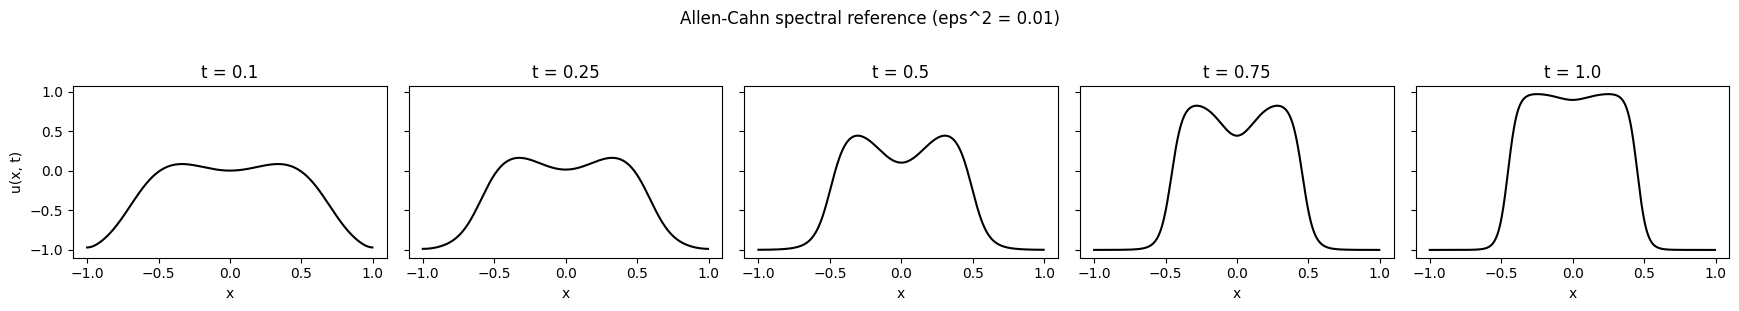

Training data: coords_pde: torch.Size([4000, 2]), coords_bc_left: torch.Size([400, 2]), coords_bc_right: torch.Size([400, 2]), coords_ic: torch.Size([800, 2]), u_ic: torch.Size([800, 1])


In [2]:
print("Computing spectral reference solution (Radau)...")
ref_snapshots = eq.compute_reference_solution()
batch = eq.generate_training_data(ref_snapshots, device=device)

snap_times = sorted(ref_snapshots.keys())
print(f"Snapshot times: {snap_times}")

fig, axes = plt.subplots(1, len(snap_times), figsize=(3.5 * len(snap_times), 3), sharey=True)
for ax, t_val in zip(axes, snap_times):
    x_ref, u_ref = ref_snapshots[t_val]
    ax.plot(x_ref, u_ref, 'k-', lw=1.5)
    ax.set_title(f't = {t_val}')
    ax.set_xlabel('x')
axes[0].set_ylabel('u(x, t)')
fig.suptitle(f'Allen-Cahn spectral reference (eps^2 = {eq.EPS2})', y=1.02)
plt.tight_layout()
plt.show()

print(f"Training data: {', '.join(f'{k}: {v.shape}' for k, v in batch.items())}")

## 2. Train LC-PINN

In [3]:
def make_live_plot_callback(title="Training"):
    def on_log(history):
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
        fig.suptitle(title)
        steps = history["step"]
        ax1.set_title("Loss components (log-log)")
        for key in history:
            if key in ("step", "total", "hw", "elapsed_sec"): continue
            ax1.plot(steps, history[key], label=key.upper(), alpha=0.7)
        ax1.plot(steps, history["total"], 'k-', lw=2, label="Total")
        ax1.set_xscale("log"); ax1.set_yscale("log")
        ax1.set_xlabel("Step"); ax1.set_ylabel("Loss")
        ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
        ax2.set_title("Total loss (semilogy)")
        ax2.semilogy(steps, history["total"], 'k-', lw=1.5)
        ax2.set_xlabel("Step"); ax2.set_ylabel("Total loss"); ax2.grid(True, alpha=0.3)
        fig.tight_layout(); plt.show(); plt.close(fig)
    return on_log

model_lc = LossConditionalPINN(eq.DIM_PHYS, eq.DIM_LAMBDA, HIDDEN_DIMS).to(device)
sampler = LambdaSampler(dim=eq.DIM_LAMBDA, device=device)

history_lc = train_lc_pinn(
    model_lc, sampler, batch, device,
    loss_fn=eq.compute_losses,
    n_epochs=N_STEPS, lr=LR, log_every=LOG_EVERY,
    on_log=make_live_plot_callback("LC-PINN (Allen-Cahn)"),
)

best_ll, best_p, _ = sweep_lambda(
    model_lc, batch, sampler, device,
    loss_fn=eq.compute_losses,
    n_candidates=500,
    exclude_terms={"pde"},
)
print(f"\nBest lambda (softmax): {best_p.cpu().numpy().round(4)}")

torch.save({
    "model_state_dict": model_lc.state_dict(),
    "best_log_lambda": best_ll,
}, "../checkpoints/allen_cahn_lc_pinn.pt")

lc_errors = eq.evaluate(model_lc, best_ll, ref_snapshots, device)
print(f"\nLC-PINN rel-L2 per snapshot: {lc_errors}")
print(f"Mean: {np.mean(list(lc_errors.values())):.4f}")

Training: 100%|██████████| 200000/200000 [1:19:33<00:00, 41.90step/s, L=8.81e-06, hw=3.00]



Training complete in 4774s (79.6 min)
Best log(lambda):     [-0.733  1.979  2.872]
Best softmax(lambda): [0.0189 0.2851 0.696 ]
Best validation loss: 6.808231e-06

Best lambda (softmax): [0.0189 0.2851 0.696 ]

LC-PINN rel-L2 per snapshot: {0.1: 0.005053773447625737, 0.25: 0.010677902099146847, 0.5: 0.029234490651148158, 0.75: 0.04565383828325929, 1.0: 0.018334906918744592}
Mean: 0.0218


## 3. Equal-weight baseline

In [4]:
model_baseline = FixedWeightPINN(eq.DIM_PHYS, HIDDEN_DIMS).to(device)
baseline_history = train_fixed_pinn(
    model_baseline,
    weights=[1/3, 1/3, 1/3],
    batch=batch, device=device,
    loss_fn=eq.compute_losses_fixed,
    n_epochs=N_STEPS, lr=LR, log_every=LOG_EVERY,
    desc="Equal-weight baseline",
    on_log=make_live_plot_callback("Equal-weight baseline (Allen-Cahn)"),
)

torch.save({"model_state_dict": model_baseline.state_dict()},
           "../checkpoints/allen_cahn_baseline.pt")

baseline_errors = eq.evaluate(model_baseline, None, ref_snapshots, device)
print(f"\nBaseline rel-L2: {baseline_errors}")
print(f"Mean: {np.mean(list(baseline_errors.values())):.4f}")

Equal-weight baseline: 100%|██████████| 200000/200000 [19:06<00:00, 174.37step/s, L=2.81e-06]

Equal-weight baseline done in 1147s (19.1 min)

Baseline rel-L2: {0.1: 0.0011005922120847784, 0.25: 0.0009622598650849798, 0.5: 0.0018296597849091743, 0.75: 0.002977160082726621, 1.0: 0.001103134233613102}
Mean: 0.0016


## 4. Comparison

Method                      t=0.10  t=0.25  t=0.50  t=0.75  t=1.00   Mean
-------------------------------------------------------------------------
LC-PINN (best lambda)       0.0051  0.0107  0.0292  0.0457  0.0183  0.0218
Equal-weight baseline       0.0011  0.0010  0.0018  0.0030  0.0011  0.0016


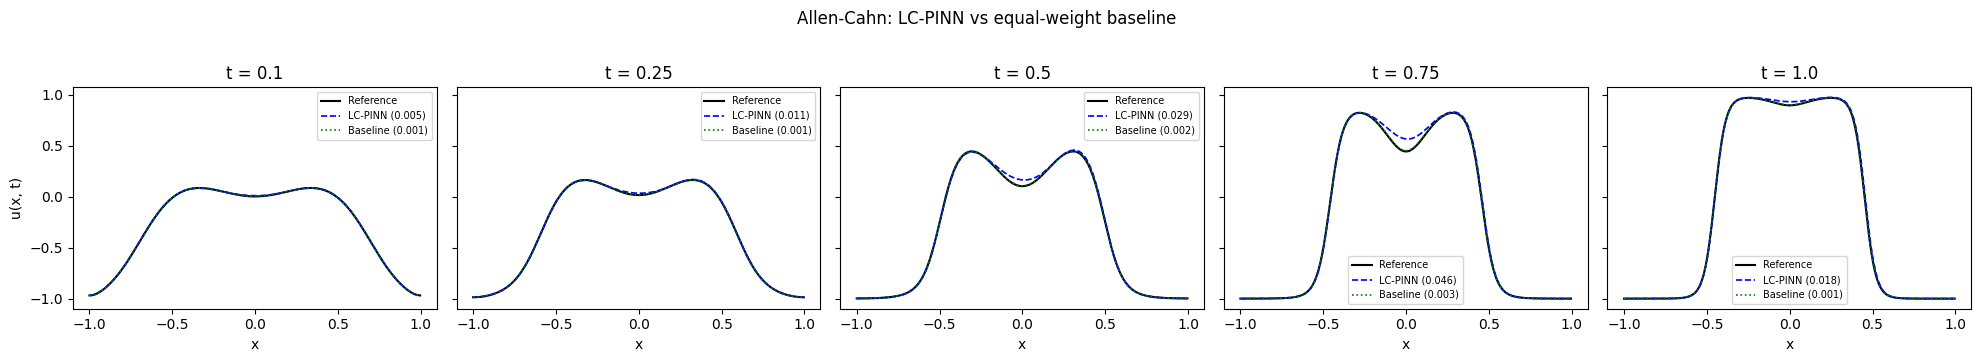

Saved: results/fig_allen_cahn_comparison.png


In [5]:
# --- Comparison table ---
results = {"LC-PINN (best lambda)": lc_errors, "Equal-weight baseline": baseline_errors}
header = f"{'Method':<26}" + "".join(f"  t={t:.2f}" for t in snap_times) + "   Mean"
print(header)
print("-" * len(header))
for name, errs in results.items():
    vals = [errs[t] for t in snap_times]
    row = f"{name:<26}" + "".join(f"  {v:.4f}" for v in vals) + f"  {np.mean(vals):.4f}"
    print(row)

# --- Side-by-side prediction plots ---
fig, axes = plt.subplots(1, len(snap_times), figsize=(4 * len(snap_times), 3.5), sharey=True)
for ax, t_val in zip(axes, snap_times):
    x_ref, u_ref = ref_snapshots[t_val]
    u_lc = eq.predict_solution(model_lc, best_ll, x_ref, t_val, device)
    u_base = eq.predict_solution(model_baseline, None, x_ref, t_val, device)
    ax.plot(x_ref, u_ref, 'k-', lw=1.5, label='Reference')
    ax.plot(x_ref, u_lc, 'b--', lw=1.2, label=f'LC-PINN ({lc_errors[t_val]:.3f})')
    ax.plot(x_ref, u_base, 'g:', lw=1.2, label=f'Baseline ({baseline_errors[t_val]:.3f})')
    ax.set_title(f't = {t_val}')
    ax.set_xlabel('x')
    ax.legend(fontsize=7)
axes[0].set_ylabel('u(x, t)')
fig.suptitle('Allen-Cahn: LC-PINN vs equal-weight baseline', y=1.02)
plt.tight_layout()
plt.savefig('../results/fig_allen_cahn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/fig_allen_cahn_comparison.png")

## 5. Uniform λ sampling ablation

Train a second LC-PINN with `mode="uniform"` and compare against the logspace LC-PINN (section 2) and equal-weight baseline (section 3).

In [ ]:
model_uniform = LossConditionalPINN(eq.DIM_PHYS, eq.DIM_LAMBDA, HIDDEN_DIMS).to(device)
sampler_uniform = LambdaSampler(dim=eq.DIM_LAMBDA, device=device, mode="uniform")

history_uniform = train_lc_pinn(
    model_uniform, sampler_uniform, batch, device,
    loss_fn=eq.compute_losses,
    n_epochs=N_STEPS, lr=LR, log_every=LOG_EVERY,
    on_log=make_live_plot_callback("LC-PINN Uniform (Allen-Cahn)"),
)

best_ll_uniform, best_p_uniform, _ = sweep_lambda(
    model_uniform, batch, sampler_uniform, device,
    loss_fn=eq.compute_losses,
    n_candidates=500,
    exclude_terms={"pde"},
)
print(f"\nBest lambda (uniform, raw weights): {best_p_uniform.cpu().numpy().round(4)}")

torch.save({
    "model_state_dict": model_uniform.state_dict(),
    "best_log_lambda": best_ll_uniform,
}, "../checkpoints/allen_cahn_lc_pinn_uniform.pt")

uniform_errors = eq.evaluate(model_uniform, best_ll_uniform, ref_snapshots, device)
print(f"\nLC-PINN (uniform) rel-L2 per snapshot: {uniform_errors}")
print(f"Mean: {np.mean(list(uniform_errors.values())):.4f}")


## 6. Three-way comparison (baseline · logspace · uniform)

In [ ]:
results = {
    "Equal-weight baseline":      baseline_errors,
    "LC-PINN (logspace, best λ)": lc_errors,
    "LC-PINN (uniform, best λ)":  uniform_errors,
}
header = f"{'Method':<30}" + "".join(f"  t={t:.2f}" for t in snap_times) + "   Mean"
print(header)
print("-" * len(header))
for name, errs in results.items():
    vals = [errs[t] for t in snap_times]
    row = f"{name:<30}" + "".join(f"  {v:.4f}" for v in vals) + f"  {np.mean(vals):.4f}"
    print(row)

fig, axes = plt.subplots(1, len(snap_times), figsize=(4 * len(snap_times), 3.5), sharey=True)
for ax, t_val in zip(axes, snap_times):
    x_ref, u_ref = ref_snapshots[t_val]
    u_lc = eq.predict_solution(model_lc, best_ll, x_ref, t_val, device)
    u_uniform = eq.predict_solution(model_uniform, best_ll_uniform, x_ref, t_val, device)
    u_base = eq.predict_solution(model_baseline, None, x_ref, t_val, device)
    ax.plot(x_ref, u_ref, 'k-', lw=1.5, label='Reference')
    ax.plot(x_ref, u_base,    'g:',  lw=1.2, label=f'Baseline ({baseline_errors[t_val]:.3f})')
    ax.plot(x_ref, u_lc,      'b--', lw=1.2, label=f'LC logspace ({lc_errors[t_val]:.3f})')
    ax.plot(x_ref, u_uniform, 'r-.', lw=1.2, label=f'LC uniform ({uniform_errors[t_val]:.3f})')
    ax.set_title(f't = {t_val}')
    ax.set_xlabel('x')
    ax.legend(fontsize=7)
axes[0].set_ylabel('u(x, t)')
fig.suptitle('Allen–Cahn: baseline vs LC-PINN (logspace) vs LC-PINN (uniform)', y=1.02)
plt.tight_layout()
plt.savefig('../results/fig_allen_cahn_three_way.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/fig_allen_cahn_three_way.png")
